In [1]:
import pandas as pd
import nltk
import re

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [5]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [6]:
import os

# List files in the dataset path to identify the CSV file
print(os.listdir(path))

# Assuming the CSV file is named 'IMDB Dataset.csv'
# Adjust the filename if it's different based on the output of os.listdir()
csv_file_path = os.path.join(path, 'IMDB Dataset.csv')
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

['IMDB Dataset.csv']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df["sentiment"])

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.8886


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[4337  624]
 [ 490 4549]]


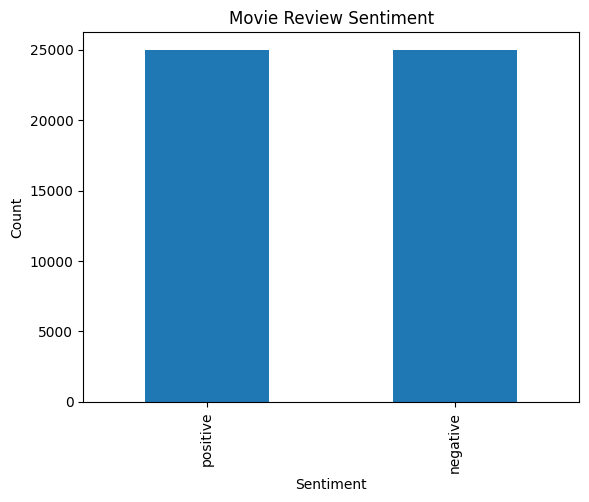

In [16]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Movie Review Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

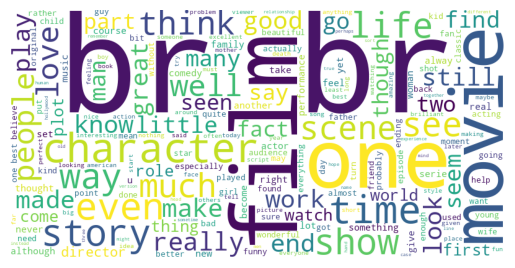

In [17]:
from wordcloud import WordCloud

positive = " ".join(df[df["sentiment"]=="positive"]["clean_review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [19]:
review = input("Enter a review: ")

clean = clean_text(review)

vector = vectorizer.transform([clean])

prediction = model.predict(vector)

print("Prediction:",encoder.inverse_transform(prediction)[0])

Enter a review: it was a very very very bad movie
Prediction: negative
